3# Task 4.3 — Comparison with Doersch (2016) VAE Tutorial

In this notebook, we compare our VAE implementation against the theoretical framework and implementation described in **Carl Doersch (2016), “Tutorial on Variational Autoencoders”** ([arXiv:1606.05908](https://arxiv.org/abs/1606.05908)).

We compare across:
1. **Architecture** — network structure, hidden units, layers
2. **Output distribution & loss** — Bernoulli vs. Gaussian, BCE vs. MSE
3. **Latent dimensionality** — sensitivity to $d$, our choice vs. Doersch’s observations
4. **Results** — reconstruction quality, generation quality, failure cases

We also train a second VAE with $d=10$ to empirically validate Doersch’s claim about dimensionality insensitivity.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from task4_vae.src.model import VAE
from task4_vae.src.train import train_vae, evaluate_vae
from task4_vae.src.analyze import (
    plot_reconstructions,
    sample_prior,
    compute_reconstruction_mse_per_digit
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Load MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Load the d=2 model from Task 4.1
vae_d2 = VAE(input_dim=784, hidden_dim=400, latent_dim=2)
ckpt_d2 = '../results/checkpoints/vae_mnist.pth'
if os.path.exists(ckpt_d2):
    vae_d2.load_state_dict(torch.load(ckpt_d2, map_location=device, weights_only=True))
    print('Loaded d=2 VAE from checkpoint')
vae_d2.to(device)
vae_d2.eval()
print(f'd=2 VAE parameters: {sum(p.numel() for p in vae_d2.parameters()):,}')

Loaded d=2 VAE from checkpoint
d=2 VAE parameters: 631,188


---
## 1. Architecture Comparison

| Aspect | Our Implementation | Doersch (2016) |
|:---|:---|:---|
| **Network Type** | MLP (fully connected) | MLP (fully connected) |
| **Encoder** | 784 → 400 (ReLU) → $\mu$, $\log\sigma^2$ | Similar MLP with hidden layers |
| **Decoder** | $z$ → 400 (ReLU) → 784 (Sigmoid) | Similar MLP with Sigmoid output |
| **Hidden Units** | 400 | Not explicitly specified (varies) |
| **Activation** | ReLU (hidden), Sigmoid (output) | ReLU (hidden), Sigmoid (output) |
| **Latent Dim** | $d=2$ (primary), $d=10$ (comparison) | Varies; notes insensitivity in broad range |

Both implementations follow the canonical VAE architecture from Kingma & Welling (2014) with a simple MLP. The key architectural choice — Sigmoid output activation — reflects the Bernoulli pixel likelihood assumption for binarised MNIST.

---
## 2. Output Distribution & Loss Comparison

| Component | Our Implementation | Doersch (2016) |
|:---|:---|:---|
| **Pixel Model** | Bernoulli per pixel | Bernoulli per pixel |
| **Output Activation** | Sigmoid → probabilities in $[0,1]$ | Sigmoid cross-entropy |
| **Recon. Loss** | `F.binary_cross_entropy(recon, x)` | Sigmoid cross-entropy (equivalent) |
| **KL Term** | Closed-form Gaussian KL | Closed-form Gaussian KL |
| **Total Loss** | $\mathcal{L} = \text{BCE} + D_{\text{KL}}$ | Same: negative ELBO |

**Match confirmed.** Doersch treats MNIST pixel intensities as Bernoulli outcome probabilities and uses sigmoid cross-entropy, which is mathematically equivalent to our `F.binary_cross_entropy` implementation. The KL divergence uses the same closed-form expression:

$$D_{\text{KL}} = \frac{1}{2} \sum_{j=1}^{d} \left( \mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1 \right)$$

---
## 3. Latent Dimensionality Experiment

Doersch (2016) observed that the VAE is **“insensitive to the dimensionality of $z$”** in a broad range, except when $z$ is very small (underfitting) or very large (unused dimensions). We validate this by training a $d=10$ VAE and comparing.

In [3]:
# Train a d=10 VAE
vae_d10 = VAE(input_dim=784, hidden_dim=400, latent_dim=10)
print(f'd=10 VAE parameters: {sum(p.numel() for p in vae_d10.parameters()):,}')
print(f'\nTraining d=10 VAE for 20 epochs...')

os.makedirs('../results/checkpoints', exist_ok=True)
history_d10 = train_vae(
    vae_d10, train_loader, epochs=20, lr=1e-3, device=device,
    save_dir='../results/checkpoints'
)

# Save d=10 checkpoint separately
torch.save(vae_d10.state_dict(), '../results/checkpoints/vae_mnist_d10.pth')
print(f'\nd=10 VAE final loss: {history_d10[-1]["loss"]:.2f}')

d=10 VAE parameters: 640,804

Training d=10 VAE for 20 epochs...


Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/20 | Loss: 162.25 (BCE: 148.86, KLD: 13.39)


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/20 | Loss: 124.64 (BCE: 107.98, KLD: 16.66)


...

Epoch 18/20 | Loss: 108.32 (BCE: 89.72, KLD: 18.60)


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20 | Loss: 108.13 (BCE: 89.47, KLD: 18.66)


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 107.85 (BCE: 89.18, KLD: 18.67)

d=10 VAE final loss: 107.85


### Test Set Loss Comparison: $d=2$ vs. $d=10$

In [4]:
test_d2 = evaluate_vae(vae_d2, test_loader, device=device)
test_d10 = evaluate_vae(vae_d10, test_loader, device=device)

print('=' * 55)
print(f'{"Metric":<25s} {"d=2":>12s} {"d=10":>12s}')
print('=' * 55)
print(f'{"Total Loss (ELBO)":<25s} {test_d2["loss"]:>12.2f} {test_d10["loss"]:>12.2f}')
print(f'{"Reconstruction (BCE)":<25s} {test_d2["bce"]:>12.2f} {test_d10["bce"]:>12.2f}')
print(f'{"KL Divergence":<25s} {test_d2["kld"]:>12.2f} {test_d10["kld"]:>12.2f}')
print('=' * 55)

Metric                             d=2         d=10
Total Loss (ELBO)               153.10       107.80
Reconstruction (BCE)            147.05        88.62
KL Divergence                     6.04        19.18


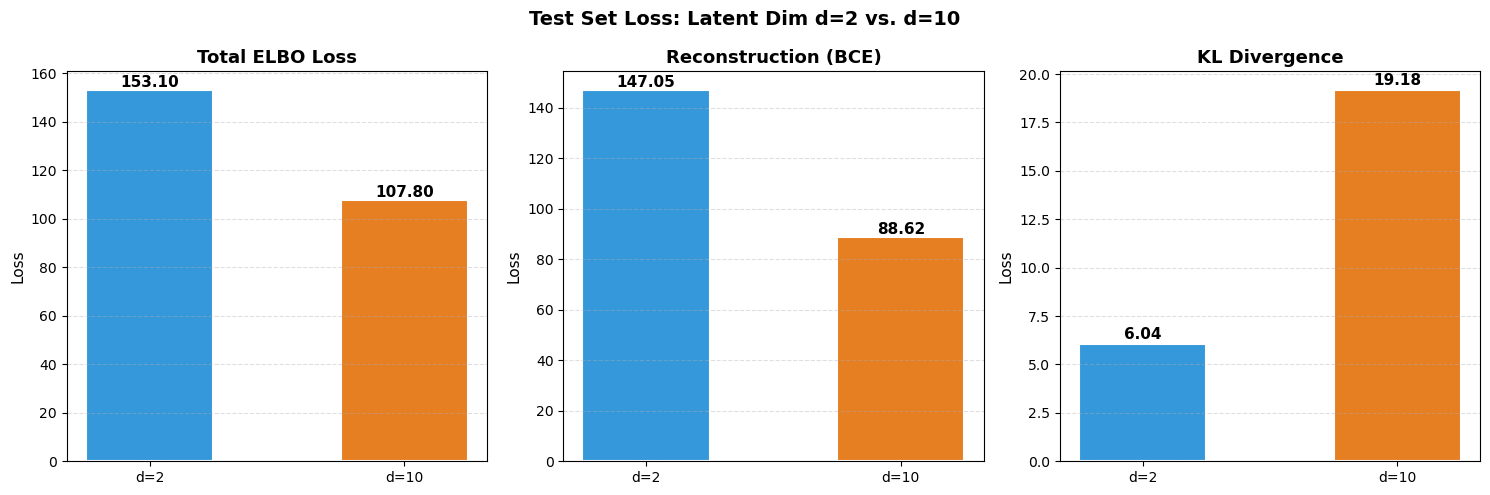

In [5]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['loss', 'bce', 'kld']
titles = ['Total ELBO Loss', 'Reconstruction (BCE)', 'KL Divergence']
colors_d2 = '#3498db'
colors_d10 = '#e67e22'

for ax, metric, title in zip(axes, metrics, titles):
    vals = [test_d2[metric], test_d10[metric]]
    bars = ax.bar(['d=2', 'd=10'], vals, color=[colors_d2, colors_d10], width=0.5,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Test Set Loss: Latent Dim d=2 vs. d=10', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/latent_dim_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Reconstruction Comparison: $d=2$ vs. $d=10$

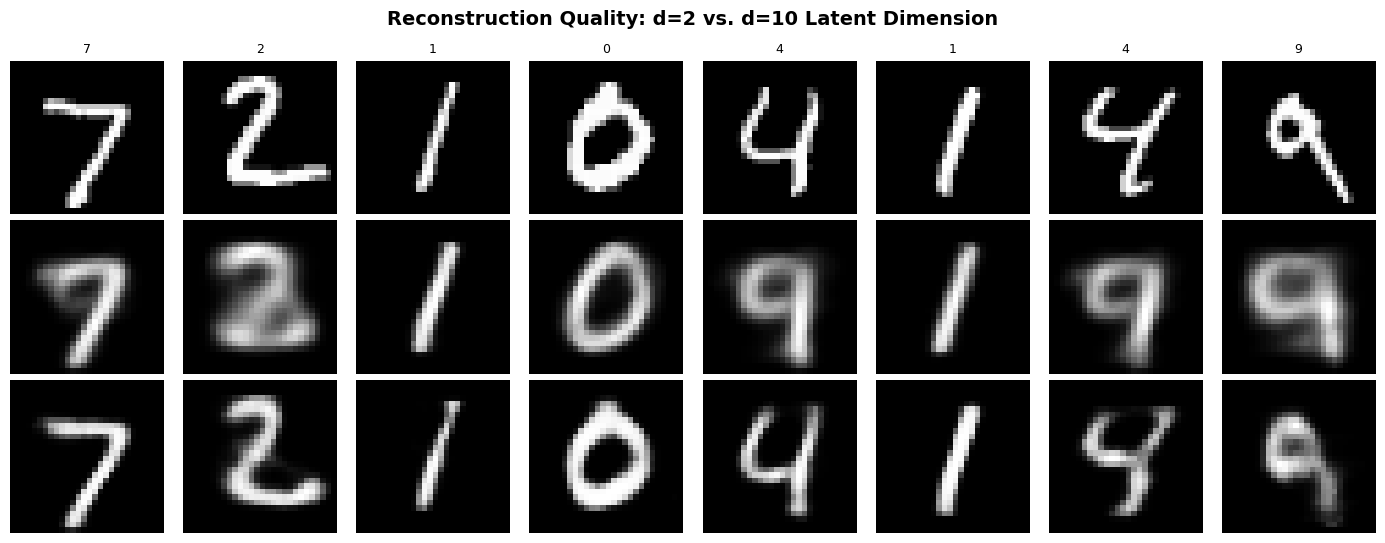

In [6]:
# Get the same batch for fair comparison
data_batch, targets_batch = next(iter(test_loader))
data_batch = data_batch[:8].to(device)

with torch.no_grad():
    recon_d2, _, _ = vae_d2(data_batch)
    recon_d10, _, _ = vae_d10(data_batch)

fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))

for i in range(8):
    axes[0, i].imshow(data_batch[i].squeeze().cpu().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{targets_batch[i].item()}', fontsize=9)

    axes[1, i].imshow(recon_d2[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_d10[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('d=2 Recon', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('d=10 Recon', fontsize=11, fontweight='bold')

fig.suptitle('Reconstruction Quality: d=2 vs. d=10 Latent Dimension', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/reconstruction_d2_vs_d10.png', bbox_inches='tight', dpi=300)
plt.show()

### Generation Comparison: $d=2$ vs. $d=10$

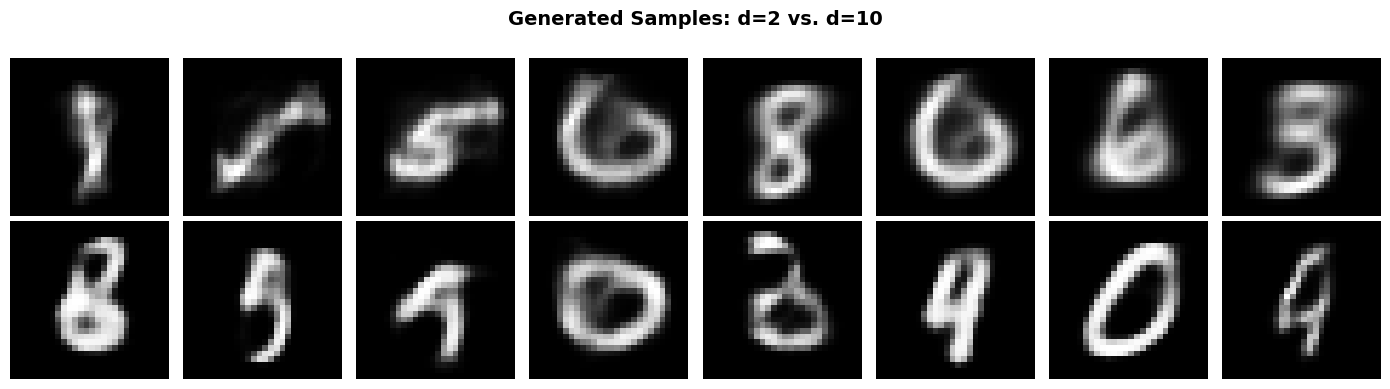

In [7]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

torch.manual_seed(42)
z_d2 = torch.randn(8, 2).to(device)
z_d10 = torch.randn(8, 10).to(device)

with torch.no_grad():
    gen_d2 = vae_d2.decode(z_d2).view(-1, 28, 28).cpu().numpy()
    gen_d10 = vae_d10.decode(z_d10).view(-1, 28, 28).cpu().numpy()

for i in range(8):
    axes[0, i].imshow(gen_d2[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(gen_d10[i], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('d=2', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('d=10', fontsize=11, fontweight='bold')

fig.suptitle('Generated Samples: d=2 vs. d=10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/generation_d2_vs_d10.png', bbox_inches='tight', dpi=300)
plt.show()

### Per-Digit MSE Comparison

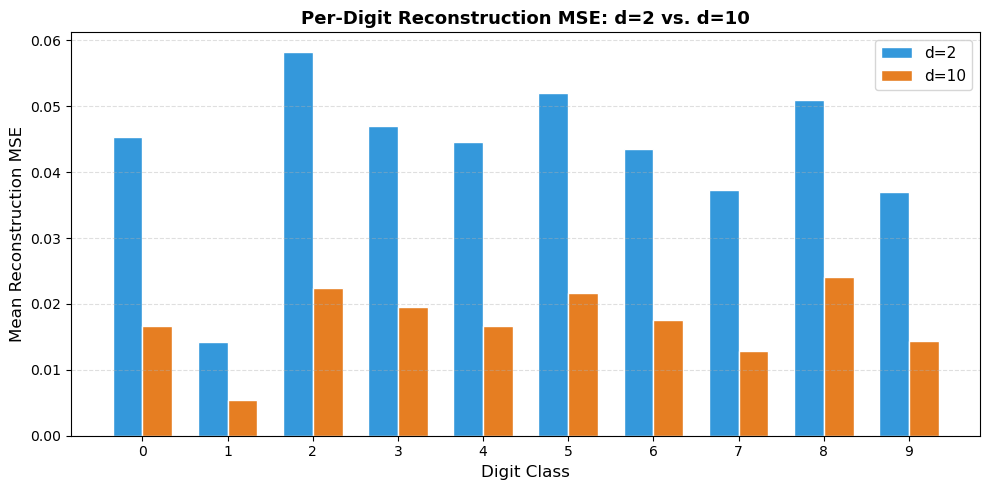

In [8]:
mse_d2 = compute_reconstruction_mse_per_digit(vae_d2, test_loader, device=device)
mse_d10 = compute_reconstruction_mse_per_digit(vae_d10, test_loader, device=device)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(10)
width = 0.35

bars1 = ax.bar(x - width/2, [mse_d2[d] for d in range(10)], width,
               label='d=2', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, [mse_d10[d] for d in range(10)], width,
               label='d=10', color='#e67e22', edgecolor='white')

ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Mean Reconstruction MSE', fontsize=12)
ax.set_title('Per-Digit Reconstruction MSE: d=2 vs. d=10', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in range(10)])
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/per_digit_mse_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Training Loss Comparison: $d=2$ vs. $d=10$

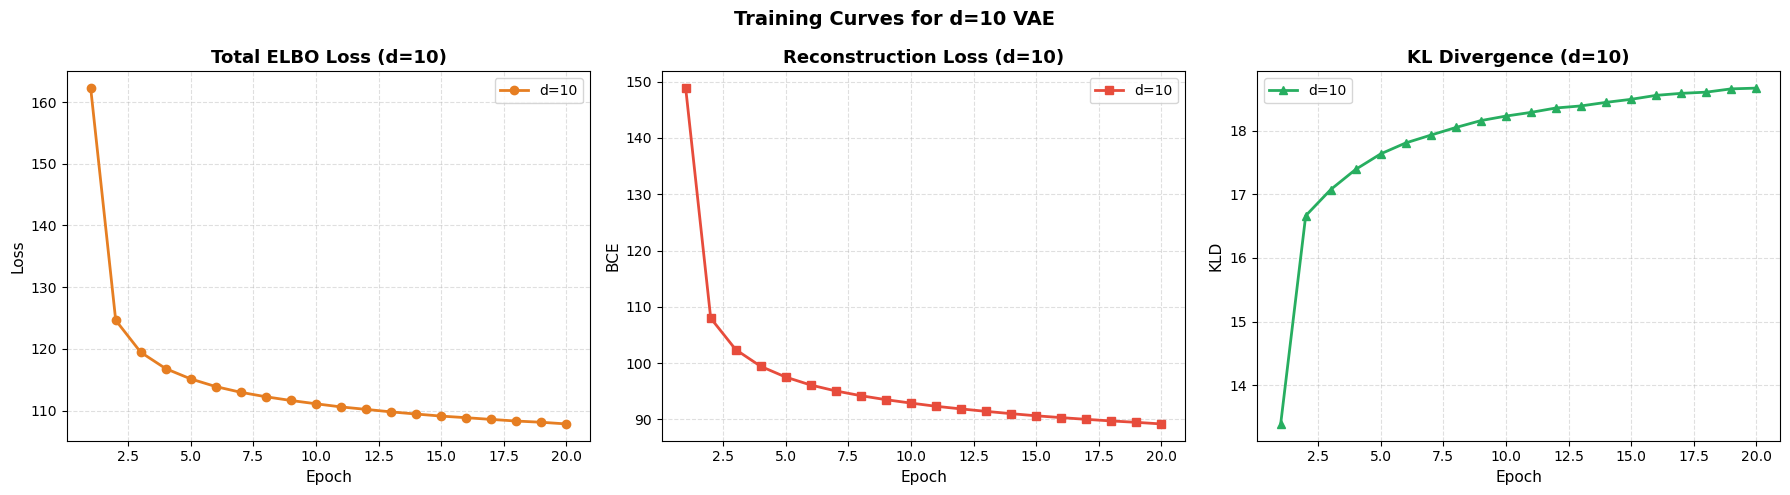

In [9]:
# Load d=2 training history from notebook 1 (approximate from test eval)
# We'll use d=10 history we just computed
epochs_d10 = [h['epoch'] for h in history_d10]
loss_d10 = [h['loss'] for h in history_d10]
bce_d10 = [h['bce'] for h in history_d10]
kld_d10 = [h['kld'] for h in history_d10]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Loss
axes[0].plot(epochs_d10, loss_d10, marker='o', color='#e67e22', linewidth=2, label='d=10')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Total ELBO Loss (d=10)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.4)

# BCE
axes[1].plot(epochs_d10, bce_d10, marker='s', color='#e74c3c', linewidth=2, label='d=10')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('BCE', fontsize=11)
axes[1].set_title('Reconstruction Loss (d=10)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.4)

# KLD
axes[2].plot(epochs_d10, kld_d10, marker='^', color='#27ae60', linewidth=2, label='d=10')
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('KLD', fontsize=11)
axes[2].set_title('KL Divergence (d=10)', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Training Curves for d=10 VAE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/training_curves_d10.png', bbox_inches='tight', dpi=300)
plt.show()